#### This script runs generate_contribution stuff using a file defined by TratamentoConfig.input variable.

In [1]:
from pathlib import Path
from generate_contribution.config import ReportConfig, TratamentoConfig
from generate_contribution.pipeline import run_pipeline
import pandas as pd

pd.set_option('display.float_format', lambda x: f'{x:.2f}')
BASE_DIR = Path.cwd()

In [3]:
tratamento_config = TratamentoConfig(
    input=BASE_DIR / "DATASET" / "Base_inicial_SA_Acesso.xlsx",
    imeta_sheet="Metadados",
    idata_sheet="Dados_RA_Acesso",
    method_boxcox="forecast",
    sigla="SA",
    subsetor="ACESSO",
    output_dir=BASE_DIR / "OUTPUT",
)

report_config = ReportConfig(
    template=BASE_DIR / "TEMPLATE" / "ADAPTA_RESUMO.pptx",
    setor_estrategico="Segurança Alimentar",
    sigla="SA",
    subsetor="ACESSO",
    caminho_shp_mun=BASE_DIR / "DATASET" / "SHP" / "BR_Municipios_2022_gr.shp",
    caminho_shp_uf=BASE_DIR / "DATASET" / "SHP" / "BR_UF_2022_gr.shp",
    ind=None,
    resu=True,
    winz=True,
    bxcx=True,
    norm=True,
    output_dir=BASE_DIR / "OUTPUT",
)

In [4]:
run_pipeline(
    tratamento_config,
    report_config,
    figs_dir=BASE_DIR / "FIGs",
    run_report=True,
    run_diagnostics=True,
)


 Arquivos .xlsx Gerados 
  D:\Atrium\Projects\adaptabrasil\generate_contribution\OUTPUT\ANALISE_DESCRITIVA_SAACESSO_2026-08-26_18h16m.xlsx
  D:\Atrium\Projects\adaptabrasil\generate_contribution\OUTPUT\DADOS_TRATADOS_SAACESSO_2026-08-26_18h16m.xlsx

1  de  22
2  de  22
3  de  22
4  de  22
5  de  22
6  de  22
7  de  22
8  de  22
9  de  22
10  de  22
11  de  22
12  de  22
13  de  22
14  de  22
15  de  22
16  de  22
17  de  22
18  de  22
19  de  22
20  de  22
21  de  22
22  de  22

   Métricas de Avaliação Calculadas.


       Figura de Contagem de NA's Gerada


       Figura de Correlação (Total) Gerada.


       Figura de Correlação (Parcial) Gerada.


    Figura VIF 
  D:\Atrium\Projects\adaptabrasil\generate_contribution\FIGs\VIF_ISimples.png
 

    Figura Alpha de Cronbach 
  D:\Atrium\Projects\adaptabrasil\generate_contribution\FIGs\AlphaCronbach_ISimples.png
 


PipelineResult(treatment=TreatmentResult(ref=       GEOCOD                    MUN  UF  CLUSTER
0     1100015  Alta Floresta D'Oeste  RO        1
1     1100023              Ariquemes  RO        1
2     1100031                 Cabixi  RO        2
3     1100049                 Cacoal  RO        1
4     1100056             Cerejeiras  RO        1
...       ...                    ...  ..      ...
5565  5222005             Vianópolis  GO        1
5566  5222054         Vicentinópolis  GO        1
5567  5222203               Vila Boa  GO        1
5568  5222302          Vila Propício  GO        2
5569  5300108               Brasília  DF        1

[5570 rows x 4 columns], resumo=ResumoResult(resumo_total=             iName    Classe    Min Quartil 1 Mediana Quartil 3     Max  \
0             MMPD  Numérico   2.33      2.89    3.09      3.36    4.06   
1         MCFSFCBR  Numérico    0.0      0.06     0.1      0.13    0.23   
2          PED(CI)  Numérico  29.17     44.88   49.59     56.87   74.82

#### Diagnostic figures generated in `FIGs/`

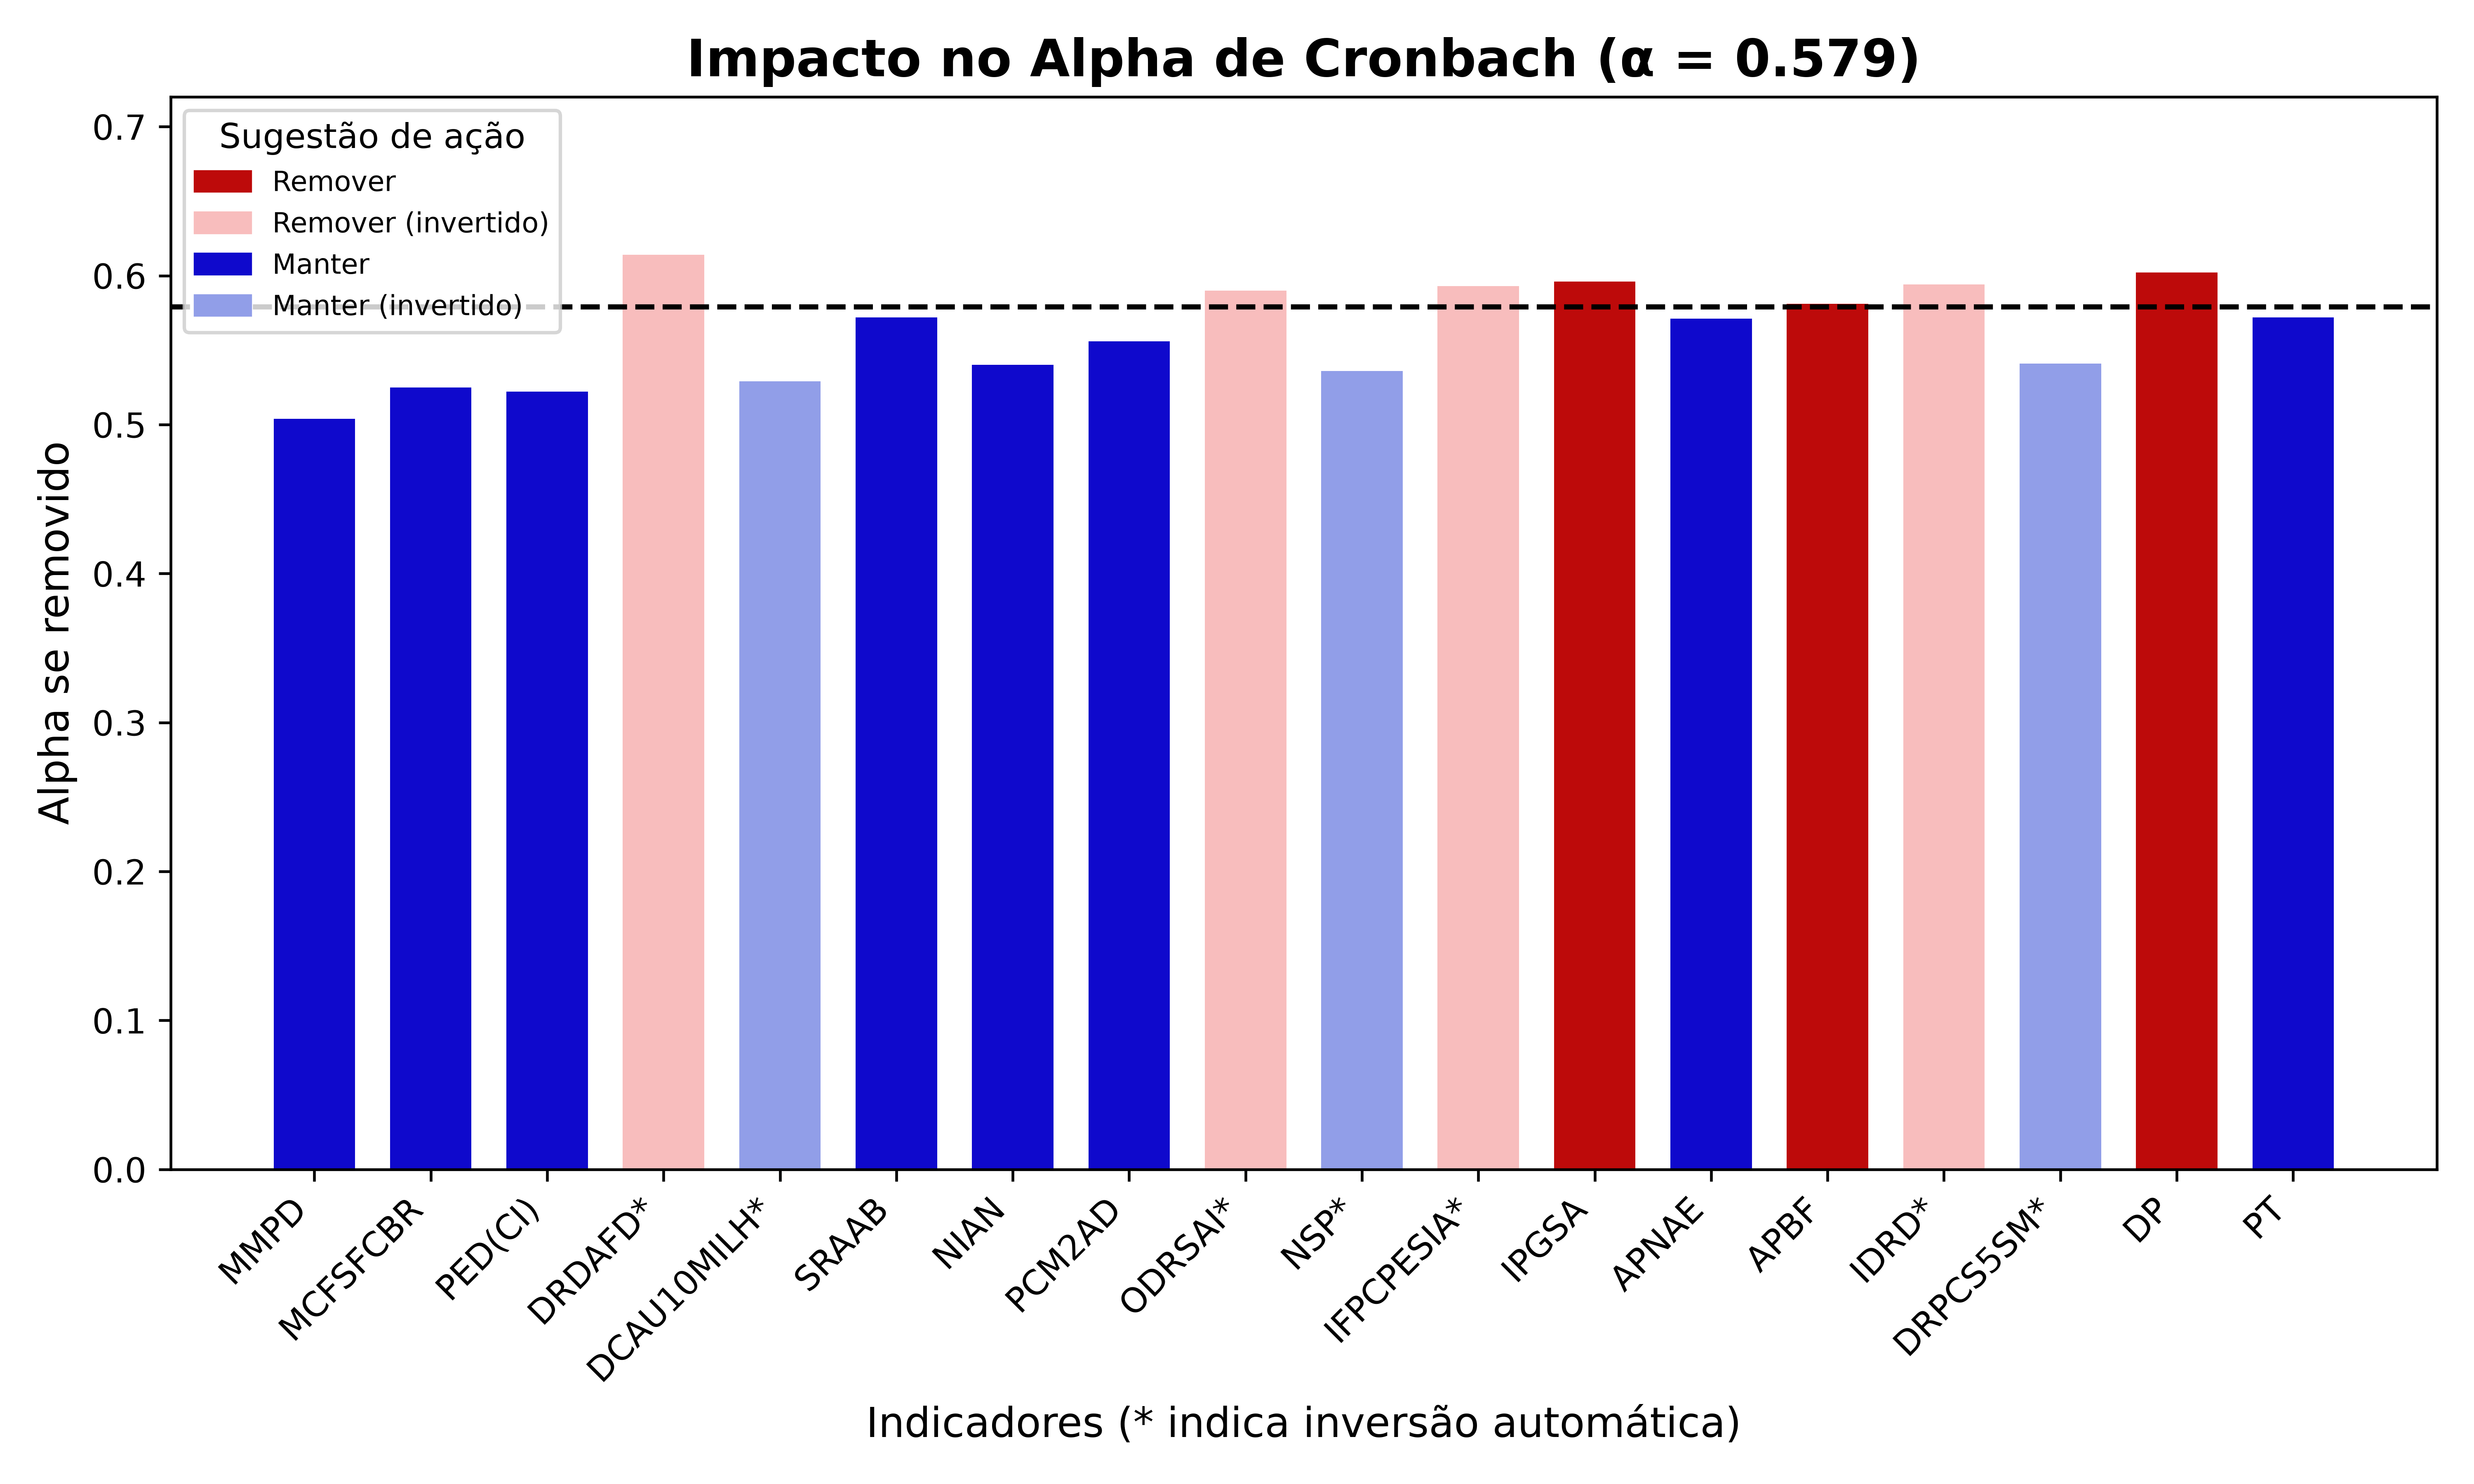

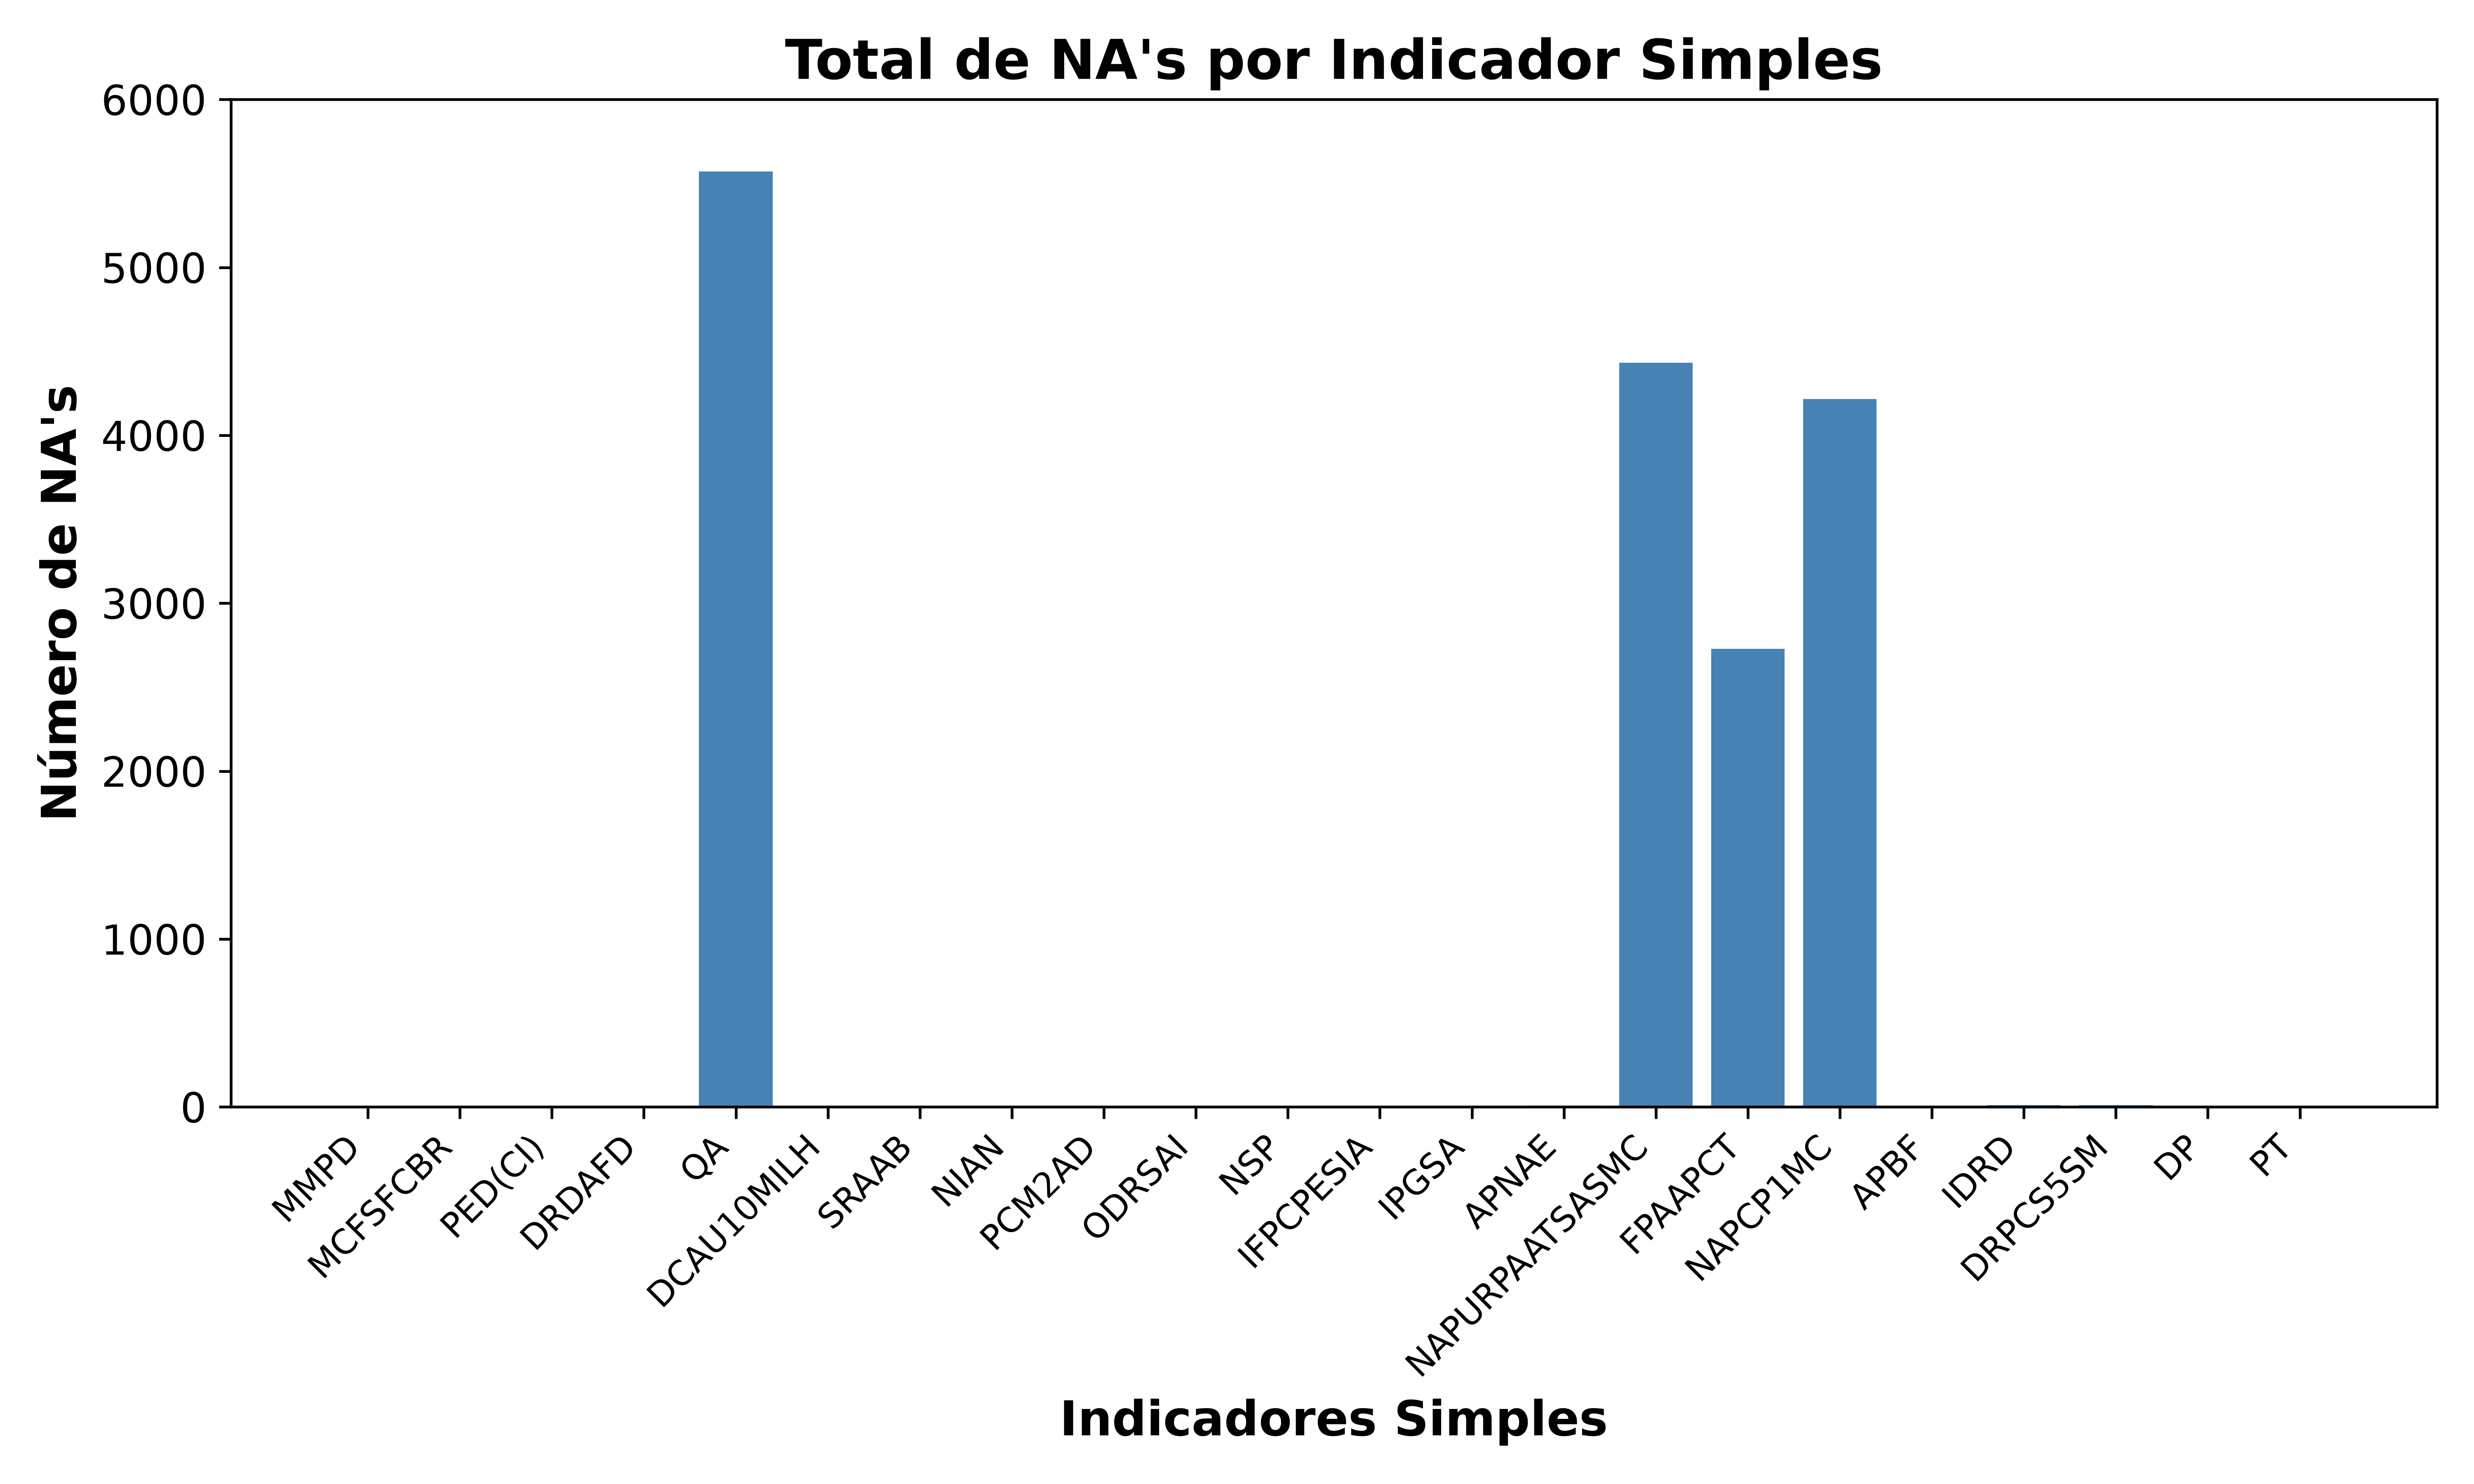

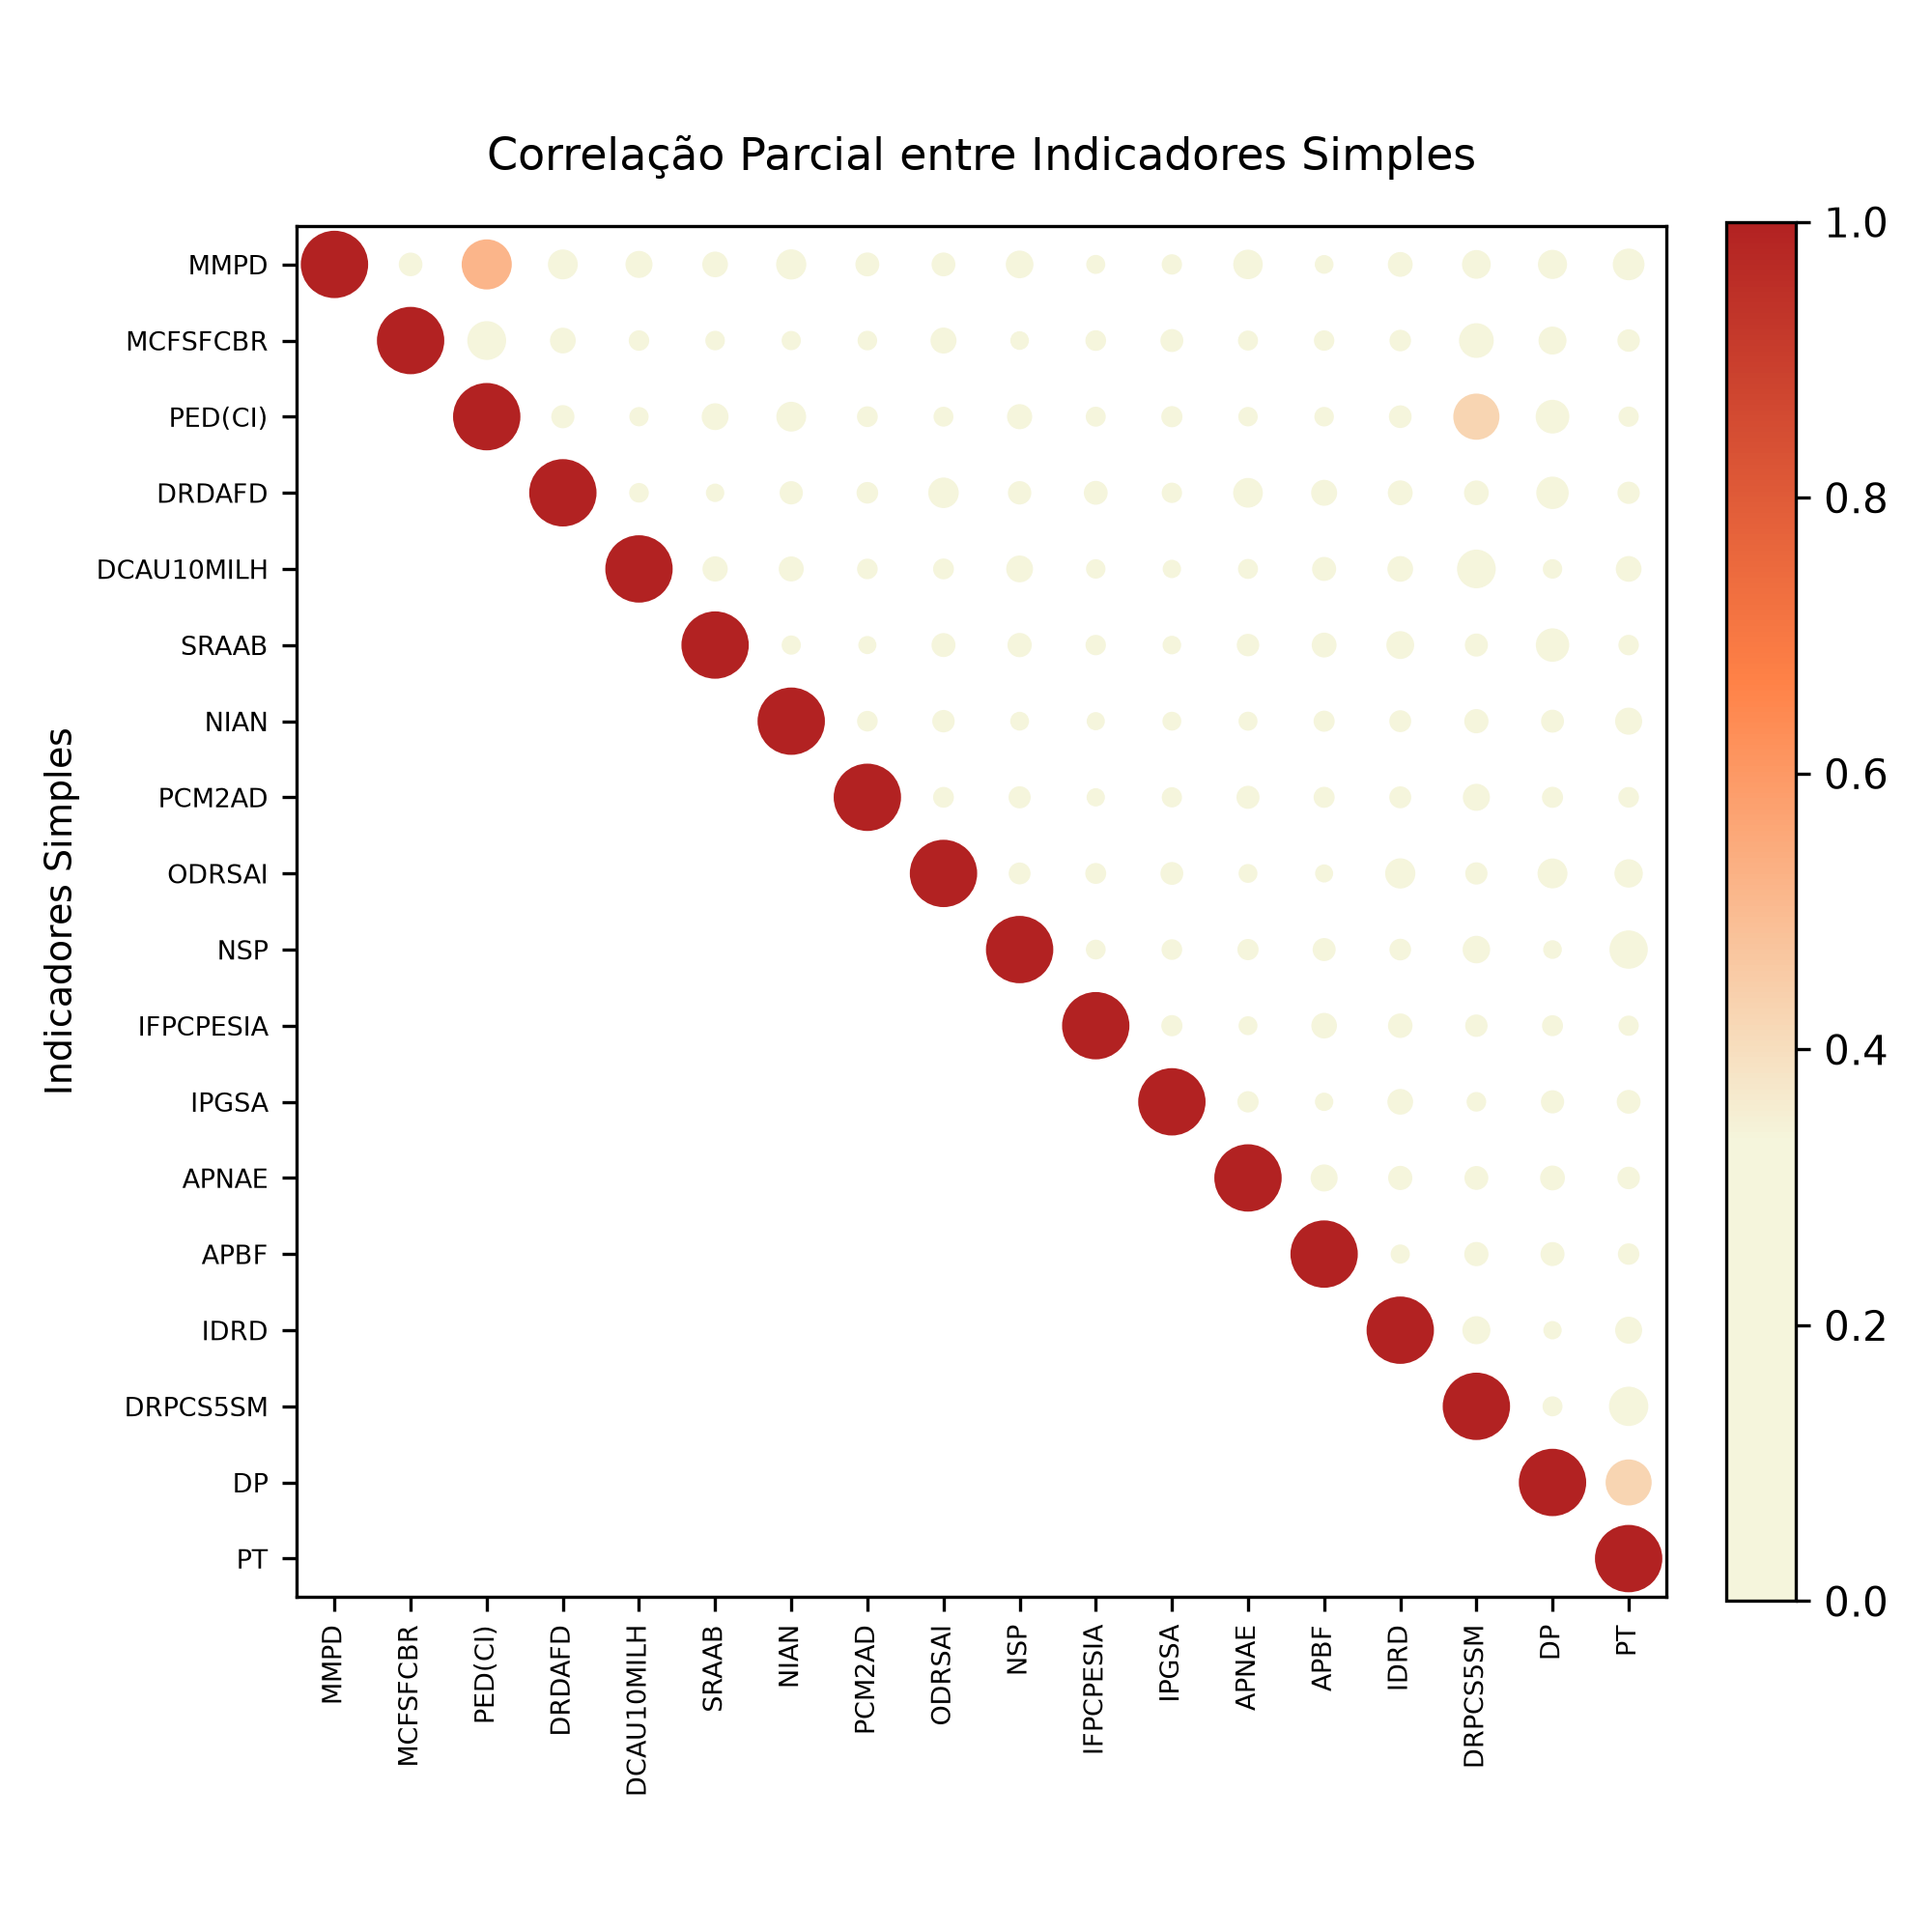

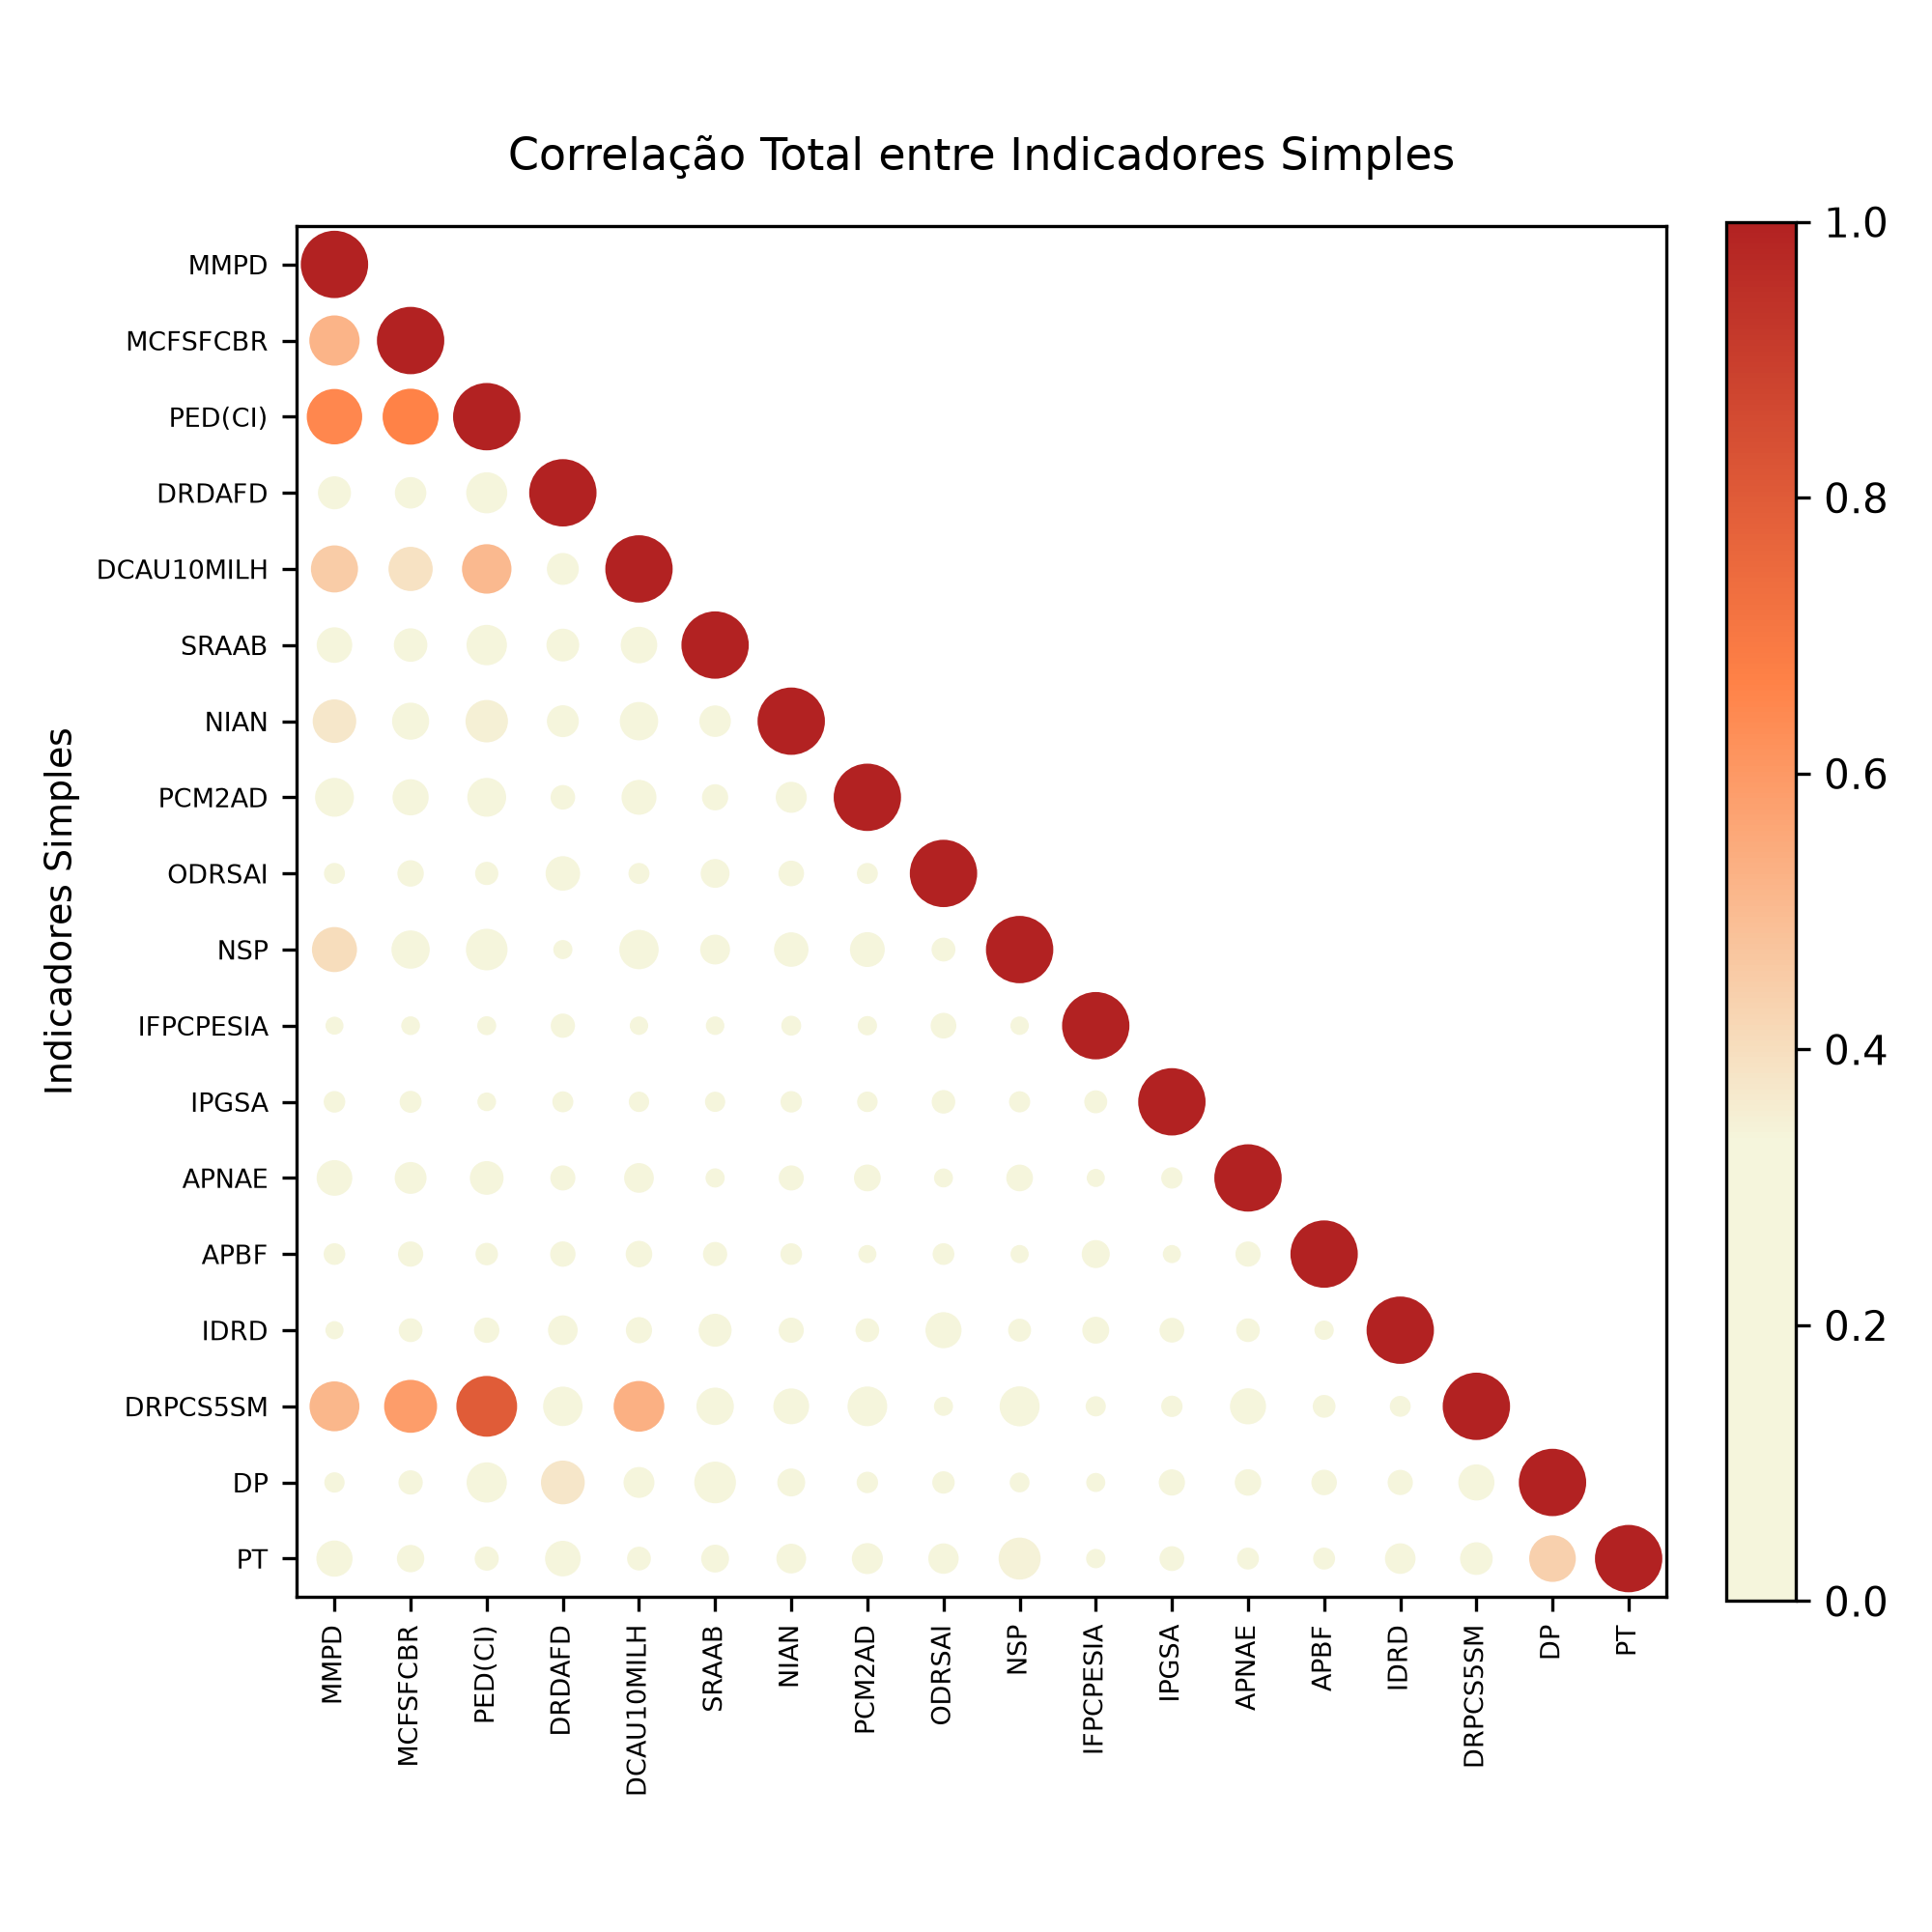

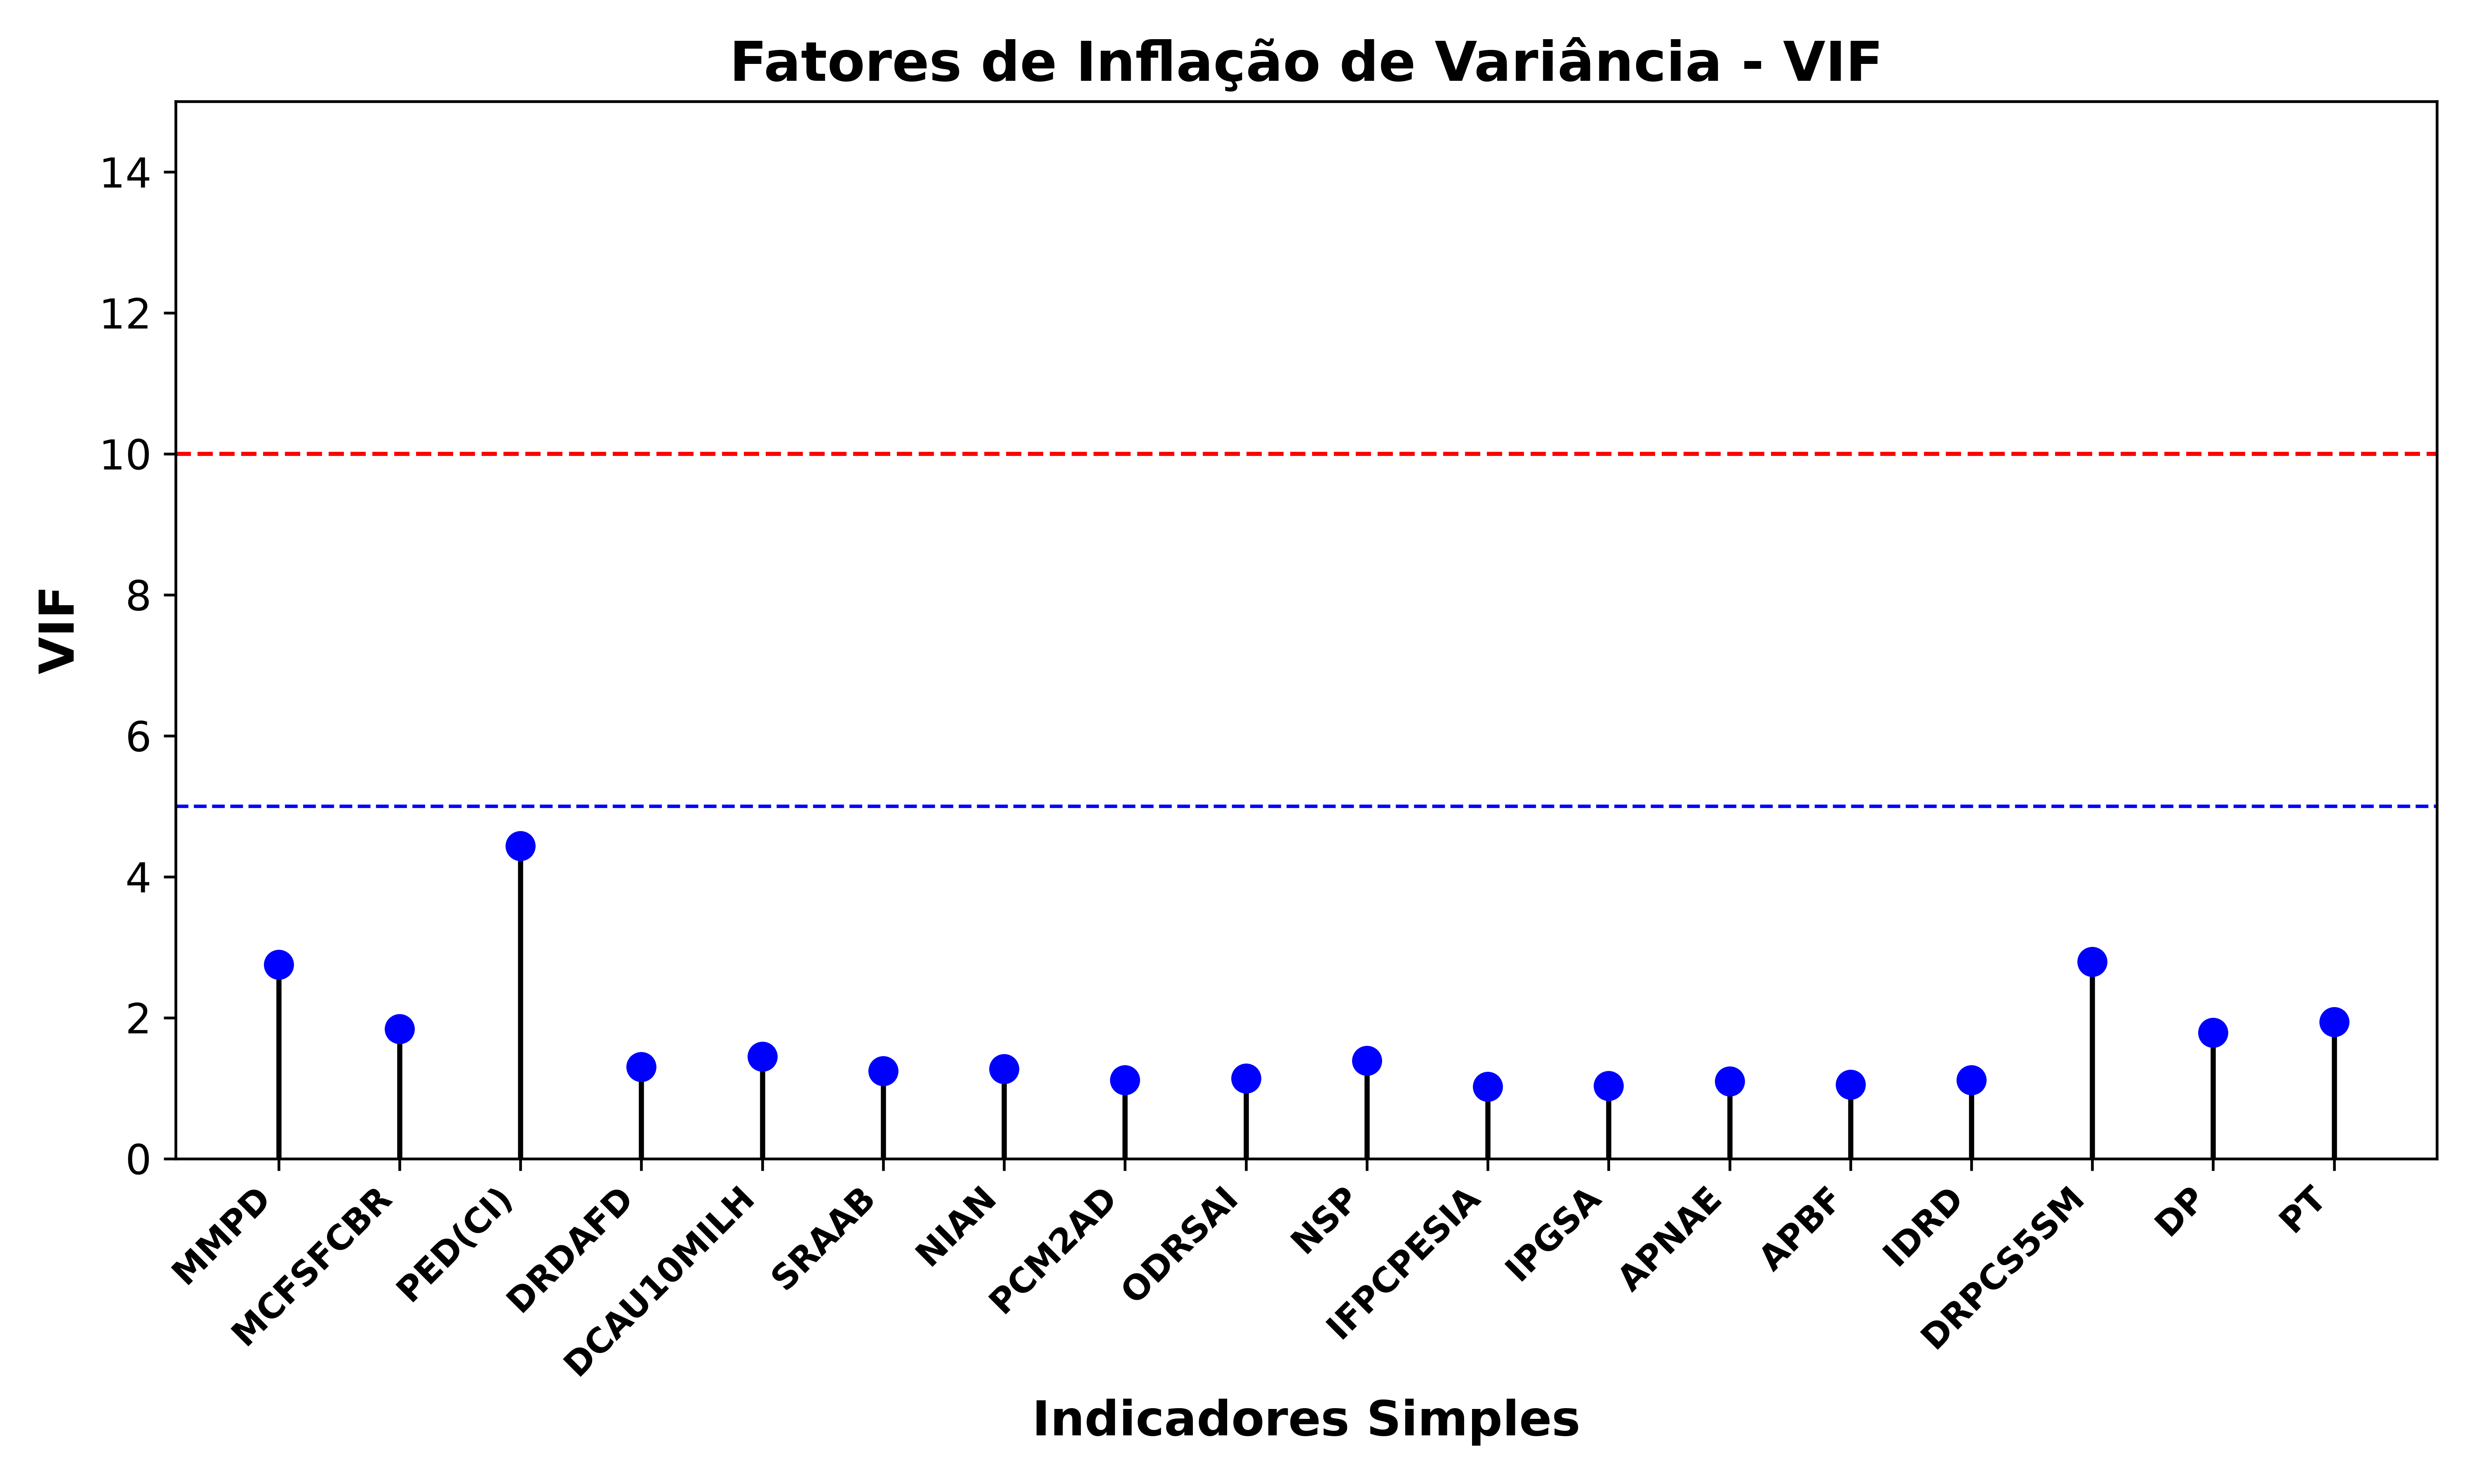

In [6]:
from IPython.display import Image, display

for p in sorted((BASE_DIR / "FIGs").glob("*.png")):
    display(Image(filename=str(p)))